# Visualizing PRE (COMPLETE) 

**Ji's Proposal:** To use `gf_reduce()`, a new function! But also to simplify the worksheet to use that method

## Chapter 7.9-7.10

In [1]:
# This code will load the R packages we will use
library(coursekata)

# set styles
css <- suppressWarnings(readLines("https://raw.githubusercontent.com/jimstigler/jupyter/master/ck_jupyter_styles_v2.css"))
IRdisplay::display_html(sprintf('<style>%s</style>', paste(css, collapse = "\n")))

# gf_resid() and gf_square_resid() are now included in the coursekata package
# gf_reduce() and gf_square_reduce() are still in beta, so this adds them
source("https://raw.githubusercontent.com/coursekata/beta-functions/refs/heads/main/gf_reduce.R")

── CourseKata packages ──────────────────────────────────── coursekata 0.19.2 ──
✔ dslabs              0.8.0       ✔ Metrics             0.1.4
✔ Lock5withR          1.2.2       ✔ lsr                 0.5.2
✔ fivethirtyeightdata 0.1.0       ✔ mosaic              1.9.1
✔ fivethirtyeight     0.6.2       ✔ supernova           3.0.0
── Conflicts ─────────────────────────────────────────── coursekata conflicts ──
✖ coursekata::outer() masks base::outer()


<div class="teacher-note">
    <b>Teacher notes: </b>The purpose of this mini-JNB is to guide students through fitting the empty and group models, calculating predictions and residuals, and visualizing each sum of squares (SS Total, SS Error, and SS Model) as actual squares to support their understanding of PRE.
    <br><br>
    <b>What changed from the paper version: </b>The old activity had students trace the empty model squares, stack the group model squares on top, and shade the leftover area to represent error reduced. That got confusing whenever a case's group model square was <i>larger</i> than its empty model square. In this version, SS Model gets its own squares via the beta function <code>gf_square_reduce()</code>: for each case, the side of the square is the distance between the group model's prediction and the empty model's prediction — the error reduced for that case. The three sets of squares add up visually: SS Total = SS Model + SS Error.
</div>

In [2]:
#load the data

id <- 1:10

date <- c("2025-06-08", "2025-06-08",
          "2025-06-09", "2025-06-09",
          "2025-06-10", "2025-06-10",
          "2025-06-11", "2025-06-11",
          "2025-06-12", "2025-06-12")
state <-  c("CA", "NV",
            "CA", "NV",
            "CA", "NV",
            "CA", "NV",
            "CA", "NV")
avg_temp <- c(70.2, 78.9,
              71.5, 80.1,
              69.8, 82.3,
              72.0, 85.0,
              73.4, 88.2)

temp_data <- data.frame(id, date, state, avg_temp)

## About the Data

The `temp_data` data frame contains a sample of daily average temperatures from California and Nevada, taken from a larger dataset collected by [NOAA](https://www.ncei.noaa.gov/products/land-based-station/nclimgrid-daily).

We're exploring whether knowing the state (California or Nevada) helps explain daily average temperature. You'll use a group model to see how much better it predicts temperature compared to just using the overall mean.

In [3]:
temp_data

id,date,state,avg_temp
<int>,<chr>,<chr>,<dbl>
1,2025-06-08,CA,70.2
2,2025-06-08,NV,78.9
3,2025-06-09,CA,71.5
4,2025-06-09,NV,80.1
5,2025-06-10,CA,69.8
6,2025-06-10,NV,82.3
7,2025-06-11,CA,72.0
8,2025-06-11,NV,85.0
9,2025-06-12,CA,73.4


## Part 1: Comparing Groups

### 1 Fit the Models

Fit the empty model and the group model (by state) to the data. Write both models in GLM notation.

In [4]:
# complete and run code here

#sample code
empty_model <- lm(avg_temp ~ NULL, data = temp_data)
empty_model

state_model <- lm(avg_temp ~ state, data = temp_data)
state_model


Call:
lm(formula = avg_temp ~ NULL, data = temp_data)

Coefficients:
(Intercept)  
      77.14  



Call:
lm(formula = avg_temp ~ state, data = temp_data)

Coefficients:
(Intercept)      stateNV  
      71.38        11.52  


One way to understand how much variation is explained by the group model is to look at the difference in means between the two groups. This is the value of b<sub>1</sub> in the model. What does this value represent in the context of temperature differences between CA and NV?

<div class="teacher-note">
    <b>Teacher notes: </b>In GLM notation the two models are:
    <br><br>
    Temp = 77.14 + Error
    <br>
    Temp = 71.38 + 11.52X<sub>1</sub> + Error
    <br><br>
    The b<sub>1</sub> value (11.52) represents the difference in average temperature between Nevada and California. It tells us how much hotter (on average) it is in Nevada compared to California in this sample.
</div>

### 2 Predictions & Residuals

Calculate the predictions and residuals of both models and save them in `temp_data`.

In [5]:
# complete and run code here

#sample code
temp_data$empty_model_pred <- predict(empty_model)
temp_data$empty_model_resid <- resid(empty_model)

temp_data$state_model_pred <- predict(state_model)
temp_data$state_model_resid <- resid(state_model)

temp_data

id,date,state,avg_temp,empty_model_pred,empty_model_resid,state_model_pred,state_model_resid
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-06-08,CA,70.2,77.14,-6.94,71.38,-1.18
2,2025-06-08,NV,78.9,77.14,1.76,82.90,-4.00
3,2025-06-09,CA,71.5,77.14,-5.64,71.38,0.12
4,2025-06-09,NV,80.1,77.14,2.96,82.90,-2.80
5,2025-06-10,CA,69.8,77.14,-7.34,71.38,-1.58
6,2025-06-10,NV,82.3,77.14,5.16,82.90,-0.60
7,2025-06-11,CA,72.0,77.14,-5.14,71.38,0.62
8,2025-06-11,NV,85.0,77.14,7.86,82.90,2.10
9,2025-06-12,CA,73.4,77.14,-3.74,71.38,2.02


### 3 Compute the SSR

Compute the sum of squared residuals (SSR) for both models. Which model makes less error?

In [6]:
# complete and run code here

#sample code
sum(resid(empty_model)^2)
sum(resid(state_model)^2)

[1] 396.844

[1] 65.068

<div class="teacher-note">
    <b>Teacher notes: </b>The SSR from the empty model is 396.844 (this is SS Total) and the SSR from the state model is 65.068 (this is SS Error). The state model reduced error by 396.844 − 65.068 = 331.776 (this is SS Model). Part 2 turns each of these three sums of squares into actual squares on a plot.
</div>

## Part 2: Visualizing PRE

On the paper worksheet you drew each residual as a vertical segment and then squared it by hand. Here, R will draw the squares for us. Each case gets a square whose side is the length of its residual — so the <b>area</b> of the square is the squared residual, and the total area of all the squares is the sum of squares.

### 4 Plot the Two Models

Make a jitter plot of temperature by state and overlay both the empty model and the state model.

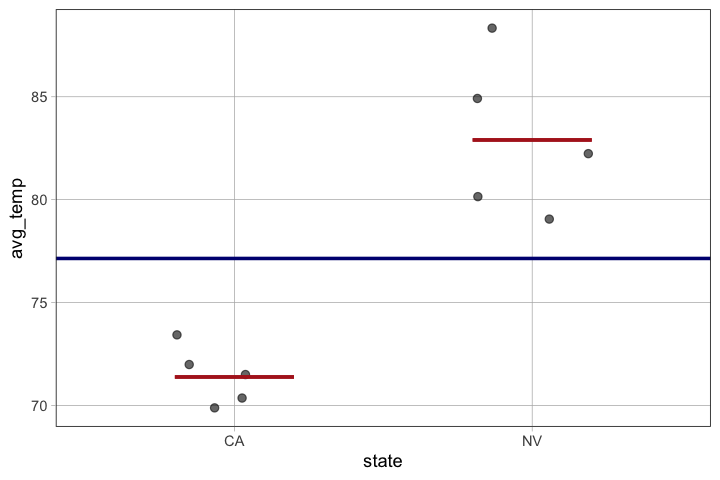

In [7]:
# complete and run code here

#sample code
gf_jitter(avg_temp ~ state, data = temp_data, width = 0.2) %>%
gf_model(empty_model, color = "navyblue") %>%
gf_model(state_model, color = "firebrick")

### 5 SS Total

Use `gf_square_resid()` to draw the squared residuals from the **empty model**. The total area of these squares is SS Total.

Which cases have the biggest squares? Why?

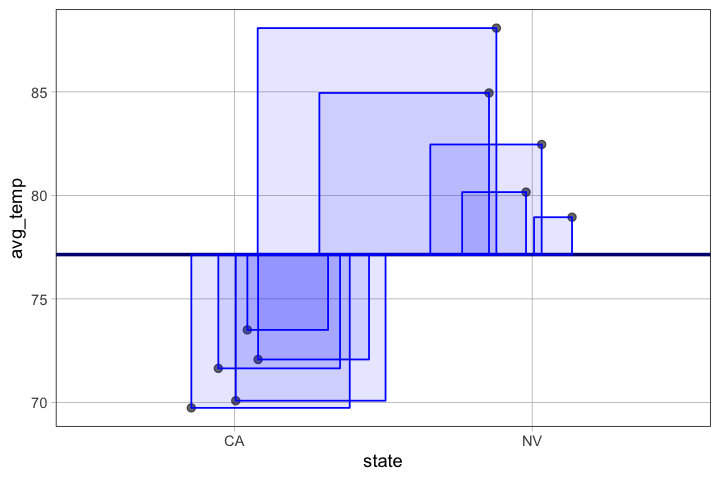

In [8]:
# complete and run code here

#sample code
gf_jitter(avg_temp ~ state, data = temp_data, width = 0.2) %>%
gf_model(empty_model, color = "navyblue") %>%
gf_square_resid(empty_model, fill = "blue", color = "blue")

<div class="teacher-note">
    <b>Teacher notes: </b>Each square hangs off a case's residual from the grand mean (77.14). The cases furthest from the grand mean (e.g., case 10, the 88.2 in NV) have the biggest squares because squaring exaggerates large residuals. Note that these squares are anchored to the empty model's horizontal line.
</div>

### 6 SS Error

Now draw the squared residuals from the **state model**. The total area of these squares is SS Error — the error that remains even after using state to predict temperature.

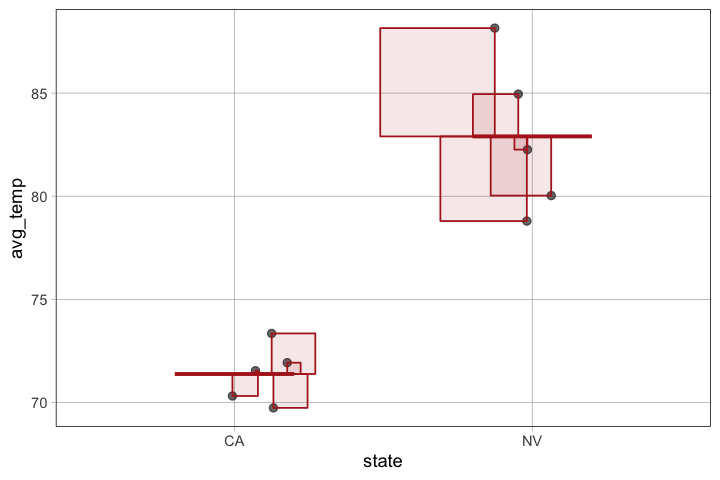

In [9]:
# complete and run code here

#sample code
gf_jitter(avg_temp ~ state, data = temp_data, width = 0.2) %>%
gf_model(state_model, color = "firebrick") %>%
gf_square_resid(state_model, fill = "firebrick", color = "firebrick")

### 7 SS Model

The error **reduced** by the state model also can be drawn as squares. For each case, `gf_square_reduce()` draws a square whose side is the distance between the state model's prediction (the group mean) and the empty model's prediction (the grand mean). The total area of these squares is SS Model.

Why are all the squares within a state the same size?

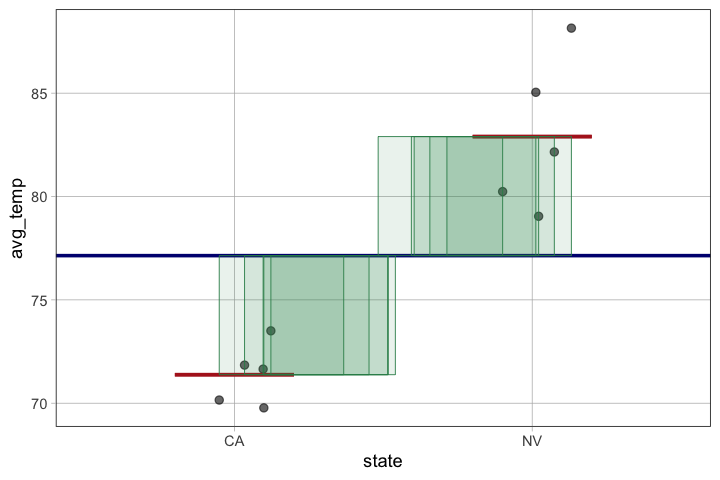

In [10]:
# complete and run code here


#sample code
gf_jitter(avg_temp ~ state, data = temp_data, width = 0.2) %>%
gf_model(empty_model, color = "navyblue") %>%
gf_model(state_model, color = "firebrick") %>%
gf_square_reduce(state_model, fill = "seagreen", color = "seagreen")

<div class="teacher-note">
    <b>Teacher notes: </b>Every case in the same state gets the same-size square because the state model makes the same prediction (the group mean) for every case in that group. Each square's side is the distance from the grand mean (77.14) to the group mean (71.38 for CA, 82.90 for NV) — 5.76 in both directions. The total green area is SS Model = 331.776, which is exactly SS Total − SS Error. In the old paper activity this was the "leftover" shaded region; now students can see it directly as its own set of squares.
</div>

### 8 Compute PRE

PRE is the proportion of total error that the model reduced:

$$PRE = \frac{SS_{Model}}{SS_{Total}} = \frac{SS_{Total} - SS_{Error}}{SS_{Total}}$$

Compute PRE from the sums of squares, then confirm your answer with `supernova()`.

In [11]:
# complete and run code here


#sample code
ss_total <- sum(resid(empty_model)^2)
ss_error <- sum(resid(state_model)^2)
ss_model <- ss_total - ss_error
ss_model

#direct method of calculating ss_model
sum((predict(state_model) - predict(empty_model))^2)

ss_model / ss_total

supernova(state_model)

[1] 331.776

[1] 331.776

[1] 0.8360363

 Analysis of Variance Table (Type III SS)
 Model: avg_temp ~ state

                              SS df      MS      F   PRE     p
 ----- --------------- | -------  - ------- ------ ----- -----
 Model (error reduced) | 331.776  1 331.776 40.791 .8360 .0002
 Error (from model)    |  65.068  8   8.133                   
 ----- --------------- | -------  - ------- ------ ----- -----
 Total (empty model)   | 396.844  9  44.094                   

Explain what PRE measures and how it helps us understand whether the group model is useful.

<div class="teacher-note">
    <b>Teacher notes: </b>PRE measures how much of the total error the group model reduced compared to the empty model. A PRE of 0.836 means that about 83.6% of the prediction error was reduced by using the state model instead of just the overall average. In the squares: the green area (SS Model) is about 83.6% of the blue area (SS Total). This shows the group model does a much better job at predicting temperature based on state.
</div>